<a href="https://colab.research.google.com/github/Yeshwanth369/ML-DL-Projects/blob/main/Pytorch_Simple_NN_Without_Optimzers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
!pip install torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch


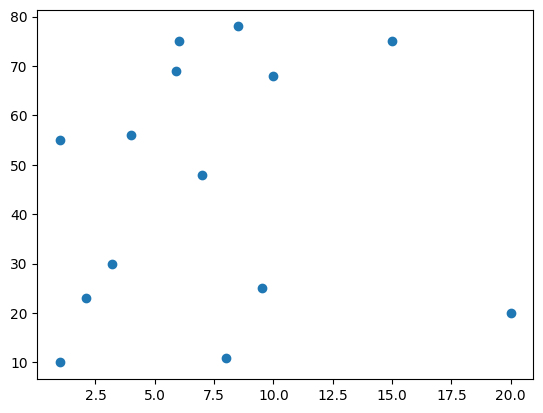

In [69]:
 x = np.array([[1,20,3.2,4,8.5,2.1,5.9,6,7,15,8,9.5,10,1]],dtype = np.float32)
 y = np.array([[10,20,30,56,78,23,69,75,48,75,11,25,68,55]],dtype = np.float32)

 plt.scatter(x,y,label = "Raw NP Data")
 plt.show()

 x_torch = torch.from_numpy(x)
 y_torch = torch.from_numpy(y)


In [70]:
x.shape

(1, 14)

In [71]:
x_torch.requires_grad #These are just input data and targets. So no need of gradients because we’re not optimizing them.
# If we are defining the Neural Net equations without torch.nn the we need to keep requires_grad = True for the weights and bias terms.

False

In [72]:
inp = 1
hidden = 5
out = 1

In [73]:
model = torch.nn.Sequential(
    torch.nn.Linear(inp,hidden),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden,out)
)
loss_fn = torch.nn.MSELoss(reduction="sum") # Mean Squared Error

In [74]:
learning_rate = 1e-5
y_pred = None


# Current x_torch is (1, 14) and inp is 1. We want (14, 1) for x_torch.
# Current y_torch is (1, 14). We want (14, 1) for y_torch.
x_torch = x_torch.T # Transposing the Matrix
y_torch = y_torch.T # Transposing the Matrix

for i in range(1,501):
  y_pred = model(x_torch)

  loss = loss_fn(y_pred,y_torch)
  print("Epoch ",i,loss.item())

  model.zero_grad() # Making the gradient to be zero 
   loss.backward()

  with torch.no_grad():
    for param in model.parameters():
      param -= learning_rate*param.grad #Updating the weights

Epoch  1 40502.296875
Epoch  2 38535.9921875
Epoch  3 36776.84765625
Epoch  4 35136.1953125
Epoch  5 33556.30078125
Epoch  6 32001.37890625
Epoch  7 30452.587890625
Epoch  8 28906.8515625
Epoch  9 27371.3671875
Epoch  10 25864.75390625
Epoch  11 24412.595703125
Epoch  12 23043.75390625
Epoch  13 21786.197265625
Epoch  14 20662.966796875
Epoch  15 19689.0546875
Epoch  16 18869.779296875
Epoch  17 18200.90234375
Epoch  18 17670.283203125
Epoch  19 17260.458984375
Epoch  20 16951.4609375
Epoch  21 16723.275390625
Epoch  22 16557.583984375
Epoch  23 16438.736328125
Epoch  24 16354.07421875
Epoch  25 16293.7861328125
Epoch  26 16250.5537109375
Epoch  27 16219.0595703125
Epoch  28 16195.541015625
Epoch  29 16177.369140625
Epoch  30 16162.76171875
Epoch  31 16150.505859375
Epoch  32 16139.7841796875
Epoch  33 16130.0654296875
Epoch  34 16120.9970703125
Epoch  35 16112.3427734375
Epoch  36 16103.9521484375
Epoch  37 16095.7265625
Epoch  38 16087.59765625
Epoch  39 16079.5244140625
Epoch  40 16

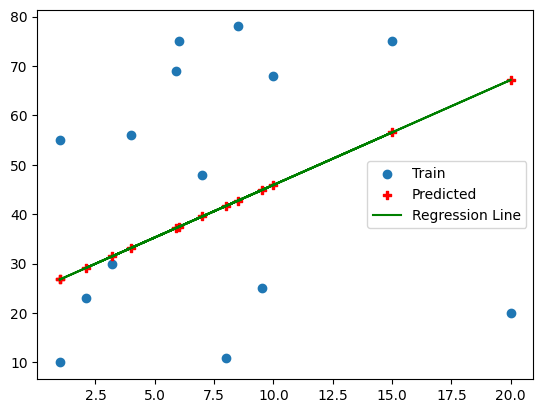

In [75]:
plt.scatter(x_torch.detach().numpy(),y_torch.detach().numpy(),label = "Train")
plt.scatter(x_torch.detach().numpy(),y_pred.detach().numpy(),color = "red", label = "Predicted",marker= "P")
plt.plot(x_torch.detach().numpy(),y_pred.detach().numpy(), color = 'green', label = "Regression Line")
plt.legend()
plt.show()

# **With Optimizer**

In [76]:
"""
optimizer_SGD = torch.nn.optim.SGD(model.parameters(), lr=0.01, )
optimizer_Adam = torch.optim.Adam(model.parameters(), lr=0.01)

for i in range(1,501):
  y_pred = model(x_torch)

  loss = loss_fn(y_pred,y_torch)
  print("Epoch ",i,loss.item())

  optimizer_adam.zero_grad()
  loss.backward()
  optimizer_adam.step()

"""

'\noptimizer_SGD = torch.nn.optim.SGD(model.parameters(), lr=0.01, )\noptimizer_Adam = torch.optim.Adam(model.parameters(), lr=0.01) \n\nfor i in range(1,501):\n  y_pred = model(x_torch)\n\n  loss = loss_fn(y_pred,y_torch)\n  print("Epoch ",i,loss.item())\n\n  optimizer_adam.zero_grad()\n  loss.backward()\n  optimizer_adam.step()\n\n'